# Stage 2A — FVM → Price Distribution

Trains per-role models mapping FVM to auction price (mean and std) from real multi-league
auction data. The models are consumed by Stage 2B (`03_regressors.ipynb`) to produce
`expprice` / `expstd` for every player.

**Input:**
- All auction files in `data/raw/{SEASON}/` and `data/raw/{SEASON-1}/`:
  - `Rose_*.xlsx` — local multi-league auction exports (IT/EN headers auto-detected)
  - `auction_{league}_{credits}_{players}.csv` — external sources (canonical schema)
- Per-season Quotazioni (`data/raw/{s}/Quotazioni_*.xlsx`) — FVM for season `{s}`,
  pairing each auction with the FVM of its own season

**Output:** `models/fvm_distribution/{SEASON}/model_[mean,std]_[P,D,C,A].joblib`

**Pipeline position:** Stage 00 → Stage 01 → **Stage 2A** → Stage 2B

**Auction semantics:** a file stored in `data/raw/{SEASON}/` is the most recent completed
auction *before* {SEASON} starts (the t-1 season auction) — the primary training input
(weight 1.0). The prior-season directory contributes with a recency weight
(`training.recency_weight`). See `docs/phase3_stage2a2b_plan.md` for the full methodology
and the canonical auction input contract (section A3).


In [1]:
import os, sys
import pandas as pd
import yaml

# Resolve repo root (notebook may run from pipeline/ or repo root)
BASE = os.getcwd()
if os.path.basename(BASE) == 'pipeline':
    BASE = os.path.abspath(os.path.join(BASE, '..'))
os.chdir(BASE)

# Load centralized config
with open('pipeline/config/stage2a2b.yaml') as _f:
    CFG = yaml.safe_load(_f)

SEASON = "25-26"
RAW_DIR = f"data/raw/{SEASON}"
INTER_DIR = f"data/intermediate/{SEASON}"
MODELS_DIR = f"models/fvm_distribution/{SEASON}"
os.makedirs(MODELS_DIR, exist_ok=True)

print(f"SEASON = {SEASON}")
print(f"RAW_DIR    = {RAW_DIR}")
print(f"INTER_DIR  = {INTER_DIR}")
print(f"MODELS_DIR = {MODELS_DIR}")


SEASON = 25-26
RAW_DIR    = data/raw/25-26
INTER_DIR  = data/intermediate/25-26
MODELS_DIR = models/fvm_distribution/25-26


In [2]:
# Load all auction data (current + prior season directories) via the canonical loader
sys.path.insert(0, BASE)  # ensure repo root is on path
from pipeline.auction_loader import load_auctions, prev_season

auctions = load_auctions(
    SEASON,
    rose_dirs=tuple(CFG['training']['rose_dirs']),
    rose_format=CFG['training']['rose_format'],
)
print(f"Loaded {len(auctions):,} auction records")
auctions.head()


Loaded 5,600 auction records


,role,name,team,price,source_file,source,league,auction_season,format_tag
0,P,Meret,Nap,40,Rose_fantalega-nicosia.xlsx,rose,fantalega-nicosia,24-25,800_8
1,P,De Gea,Fio,2,Rose_fantalega-nicosia.xlsx,rose,fantalega-nicosia,24-25,800_8
2,P,Caprile,Cag,1,Rose_fantalega-nicosia.xlsx,rose,fantalega-nicosia,24-25,800_8
3,D,Gabbia,Mil,1,Rose_fantalega-nicosia.xlsx,rose,fantalega-nicosia,24-25,800_8
4,D,Tomori,Mil,19,Rose_fantalega-nicosia.xlsx,rose,fantalega-nicosia,24-25,800_8


In [3]:
# Per-file summary
summary = (
    auctions.groupby(['auction_season', 'source_file'])
    .agg(records=('price', 'size'),
         teams=('team', 'nunique'),
         players=('name', 'nunique'),
         price_min=('price', 'min'),
         price_max=('price', 'max'),
         price_mean=('price', 'mean'))
    .reset_index()
)
print(summary.to_string(index=False))
print()
print("Role split:", auctions['role'].value_counts().to_dict())
print("Format tags:", sorted(auctions['format_tag'].unique().tolist()))
print("Leagues:", sorted(auctions['league'].unique().tolist()))

# Player appearance counts across the loaded auctions
counts = auctions.groupby(['role', 'name']).size()
print(f"\nPlayers: {len(counts)} total, appearances per player: "
      f"{counts.value_counts().sort_index().to_dict()}")


auction_season                 source_file  records  teams  players  price_min  price_max  price_mean
         23-24 Rose_fantalega-nicosia.xlsx     2800     20      305          1        400   31.389643
         24-25 Rose_fantalega-nicosia.xlsx     2800     20      317          0        341   30.832143

Role split: {'D': 1792, 'C': 1792, 'A': 1344, 'P': 672}
Format tags: ['800_8']
Leagues: ['fantalega-nicosia']

Players: 454 total, appearances per player: {1: 67, 2: 26, 3: 16, 4: 17, 5: 11, 6: 14, 7: 10, 8: 16, 9: 14, 10: 13, 11: 9, 12: 13, 13: 18, 14: 75, 15: 8, 16: 7, 17: 7, 18: 7, 19: 5, 20: 7, 21: 4, 22: 3, 23: 7, 24: 1, 25: 2, 26: 4, 27: 12, 28: 61}


In [4]:
# Loader invariant checks (fail loudly on violations)
assert set(auctions['role']) <= {'P', 'D', 'C', 'A'}, "unexpected role values"
assert (auctions['price'] >= 0).all(), "negative prices found"
assert auctions['name'].notna().all(), "missing player names"
assert (auctions['name'].str.len() > 0).all(), "empty player names"
assert auctions['price'].dtype.kind in 'iu', "price must be integer"
print("Loader invariants OK")


Loader invariants OK


## Training Data Assembly (A4-A5)

**Contemporaneous FVM pairing (A5).** Each auction is paired with the FVM of *its own
season* (from that season's `Quotazioni_*.xlsx`): the 24-25 auction (stored in
`data/raw/25-26/`) uses the 24-25 FVM, the 23-24 auction (stored in `data/raw/24-25/`)
uses the 23-24 FVM. This keeps the FVM -> price pairing consistent: using the
current-season FVM for older auctions would mix stale market values with current FVMs.
At inference time (Stage 2B) the current-season FVM is fed in, which is exactly what
the next season's auction will price.

**Recency weighting (A4).** Every training point is weighted by how recent its auction
is: the most recent auction (stored in `data/raw/{SEASON}`, the t-1 season auction)
gets weight `1.0`, older auctions get `training.recency_weight` (0.7). Market
valuations drift season over season, so recent prices should dominate.

**Aggregation + min_count (A5).** A Rose file contains every transaction of every
fantasy team across all leagues of the export, so the same real player appears many
times (once per buying team). Prices are aggregated per `(role, name, auction)`:
mean price + transaction count. `min_count` (8) = minimum number of auction transactions
per player per auction (legacy semantics: enough transactions for a reliable market
price).


In [5]:
import numpy as np
from pathlib import Path
from pipeline.auction_loader import load_season_fvm

# --- A5: contemporaneous FVM per auction season ------------------------------
# The 24-25 auction pairs with the 24-25 FVM, the 23-24 auction with the 23-24 FVM.
fvm_maps = {s: load_season_fvm(s) for s in sorted(auctions["auction_season"].unique())}
for s, m in fvm_maps.items():
    print(f"FVM {s}: {len(m)} players")
fvm_all = pd.concat([m.assign(auction_season=s) for s, m in fvm_maps.items()], ignore_index=True)
auctions["name_key"] = auctions["name"].str.strip().str.lower()
auctions = auctions.merge(fvm_all, on=["auction_season", "role", "name_key"], how="left")
print(f"Records with contemporaneous FVM: {auctions['fvm'].notna().sum()}/{len(auctions)}")

# --- A4: recency weights + per-(player, auction) price aggregation -----------
# Most recent auction (stored in data/raw/{SEASON}) gets weight 1.0, older 0.7.
latest_auction = prev_season(SEASON)
auctions["weight"] = np.where(
    auctions["auction_season"] == latest_auction, 1.0, CFG["training"]["recency_weight"]
)


def _agg(g: pd.DataFrame) -> pd.Series:
    """Mean price + transaction count for one (player, auction)."""
    return pd.Series({"price": g["price"].mean(),
                      "records": len(g),
                      "weight": g["weight"].iloc[0]})


train = (
    auctions[auctions["fvm"].notna()]
    .groupby(["role", "name_key", "auction_season", "fvm"], group_keys=False)
    .apply(_agg, include_groups=False)
    .reset_index()
)
name_map = (auctions.drop_duplicates(["role", "name_key"])
            .set_index(["role", "name_key"])["name"].to_dict())
train["name"] = [name_map[(r, n)] for r, n in zip(train["role"], train["name_key"])]
train = train[train["records"] >= CFG["training"]["min_count"]].reset_index(drop=True)
print(f"Training points (player, auction) with >= {CFG['training']['min_count']} "
      f"transactions: {len(train)}")
print(train.groupby("role")["records"].agg(["count", "min", "max"]).to_string())
train[["role", "name", "auction_season", "price", "records", "fvm"]].head(10)


FVM 23-24: 539 players
FVM 24-25: 529 players
Records with contemporaneous FVM: 5569/5600
Training points (player, auction) with >= 8 transactions: 378
      count  min   max
role                  
A        90  9.0  14.0
C       124  8.0  14.0
D       118  8.0  14.0
P        46  8.0  14.0


,role,name,auction_season,price,records,fvm
0,A,Abraham,24-25,30.785714,14.0,30.0
1,A,Adams C.,24-25,30.000000,14.0,72.0
2,A,Almqvist,23-24,4.785714,14.0,28.0
3,A,Arnautovic,23-24,32.785714,14.0,122.0
4,A,Belotti,23-24,5.928571,14.0,52.0
5,A,Beltran L.,23-24,14.071429,14.0,61.0
6,A,Beltran L.,24-25,3.307692,13.0,34.0
7,A,Berardi,23-24,176.357143,14.0,271.0
8,A,Bonny,24-25,20.357143,14.0,42.0
9,A,Cambiaghi,23-24,3.888889,9.0,28.0


In [6]:
# --- A5: per-role FVM floor ---------------------------------------------------
floors = CFG["training"]["fvm_floor"]
train = train[train.apply(lambda r: r["fvm"] >= floors[r["role"]], axis=1)].reset_index(drop=True)
print(f"Training points after FVM floors {floors}: {len(train)}")
print(train.groupby("role")["records"].agg(["count", "min", "max"]).to_string())


Training points after FVM floors {'P': 1, 'D': 10, 'C': 1, 'A': 1}: 374
      count  min   max
role                  
A        90  9.0  14.0
C       124  8.0  14.0
D       114  8.0  14.0
P        46  8.0  14.0


## Mean Model (B1, B3)

`Ridge([sqrt(FVM), FVM])` per role, fit on aggregated player prices with sample weights =
record weights (recency). `sqrt(FVM)` captures the sub-linear growth at low FVM, `FVM` the
acceleration at high FVM. The legacy baseline `LinearRegression([FVM])` is also fit
in-sample for comparison (acceptance: Ridge MAE < baseline in >= 3/4 roles).


In [7]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from pipeline.price_models import make_features, predict_price

alpha = CFG["model"]["ridge_alpha"]
mean_models = {}
score_rows = []
for role in CFG["roles"]["major"]:
    sub = train[train["role"] == role]
    X, y, w = make_features(sub["fvm"]), sub["price"].to_numpy(float), sub["weight"].to_numpy(float)
    model = Pipeline([("scaler", StandardScaler()), ("ridge", Ridge(alpha=alpha))])
    model.fit(X, y, ridge__sample_weight=w)
    mean_models[role] = model
    base = LinearRegression().fit(sub["fvm"].to_numpy(float).reshape(-1, 1), y, sample_weight=w)
    mae = float(np.abs(model.predict(X) - y).mean())
    mae_base = float(np.abs(base.predict(sub["fvm"].to_numpy(float).reshape(-1, 1)) - y).mean())
    score_rows.append({"role": role, "n": len(sub), "mae": round(mae, 2),
                       "baseline_mae": round(mae_base, 2), "improved": mae < mae_base})
scores = pd.DataFrame(score_rows)
print("In-sample fit (Ridge sqrt vs legacy LinearRegression baseline):")
print(scores.to_string(index=False))
improved_roles = scores.loc[scores["improved"], "role"].tolist()


In-sample fit (Ridge sqrt vs legacy LinearRegression baseline):
role   n   mae  baseline_mae  improved
   P  46  6.22          7.45      True
   D 114  5.68          5.70      True
   C 124  8.83          8.80     False
   A  90 16.55         17.80      True


## Std Model (B2)

Two stages, per role:

1. **Binned empirical std** — players are binned by FVM (width `model.std_bin_width` = 10);
   each bin's weighted std of prices is a non-parametric `std(FVM)` estimate.
2. **Ridge smoothing** — a `Ridge([FVM])` is fit on the qualifying bin centers
   (bins with `count >= training.min_count`; relaxed to `count >= 3` if too few bins
   qualify), weighted by bin size. This smooths noisy bins while preserving the shape.

Predictions are clipped to `[model.std_min, 150]`. Both models are saved as joblib
(StandardScaler + Ridge pipelines), the same layout as the legacy models.


In [8]:
def fit_std_model(sub: pd.DataFrame, bin_width: int, min_count: int, std_min: float, alpha: float):
    """Binned empirical std smoothed by Ridge (B2). Returns (model, bin_df)."""
    fvm = sub["fvm"].to_numpy(float)
    price = sub["price"].to_numpy(float)
    w = sub["weight"].to_numpy(float)
    edges = np.arange(np.floor(fvm.min()), np.ceil(fvm.max()) + bin_width, bin_width)
    idx = np.clip(np.digitize(fvm, edges) - 1, 0, len(edges) - 2)
    centers, stds, counts = [], [], []
    for b in range(len(edges) - 1):
        m = idx == b
        if not m.any():
            continue
        mu = (price[m] * w[m]).sum() / w[m].sum()
        var = (w[m] * (price[m] - mu) ** 2).sum() / w[m].sum()
        centers.append((edges[b] + edges[b + 1]) / 2)
        stds.append(max(float(np.sqrt(var)), std_min))
        counts.append(int(m.sum()))
    bin_df = pd.DataFrame({"center": centers, "std": stds, "count": counts})
    keep = bin_df["count"] >= min_count
    if keep.sum() < 5:  # too few qualifying bins: relax to the statistical minimum
        keep = bin_df["count"] >= 3
    X = bin_df.loc[keep, "center"].to_numpy(float).reshape(-1, 1)
    model = Pipeline([("scaler", StandardScaler()), ("ridge", Ridge(alpha=alpha))])
    model.fit(X, bin_df.loc[keep, "std"].to_numpy(float),
              ridge__sample_weight=bin_df.loc[keep, "count"].to_numpy(float))
    return model, bin_df


std_models, std_bins = {}, {}
for role in CFG["roles"]["major"]:
    sub = train[train["role"] == role]
    std_models[role], std_bins[role] = fit_std_model(
        sub, CFG["model"]["std_bin_width"], CFG["training"]["min_count"],
        CFG["model"]["std_min"], alpha,
    )
    b = std_bins[role]
    print(f"Role {role}: {len(b)} bins, {int((b['count'] >= CFG['training']['min_count']).sum())} "
          f"with >= {CFG['training']['min_count']} players")

# --- Save models (same layout as legacy) -----------------------------------
import joblib
for role in CFG["roles"]["major"]:
    joblib.dump(mean_models[role], Path(MODELS_DIR) / f"model_mean_{role}.joblib")
    joblib.dump(std_models[role], Path(MODELS_DIR) / f"model_std_{role}.joblib")
print(f"Saved 8 models to {MODELS_DIR}")


Role P: 11 bins, 1 with >= 8 players
Role D: 9 bins, 4 with >= 8 players
Role C: 15 bins, 7 with >= 8 players
Role A: 32 bins, 2 with >= 8 players
Saved 8 models to models/fvm_distribution/25-26


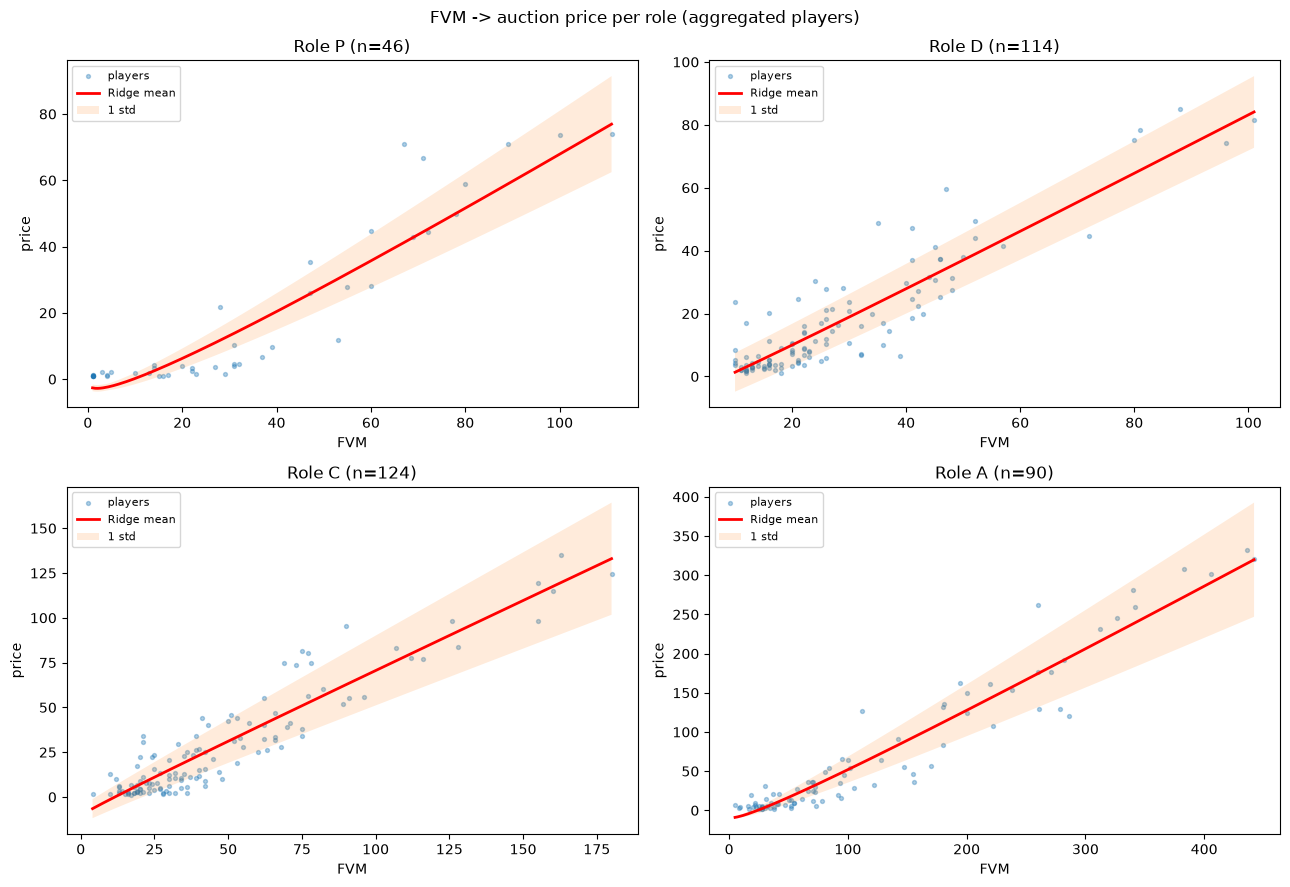

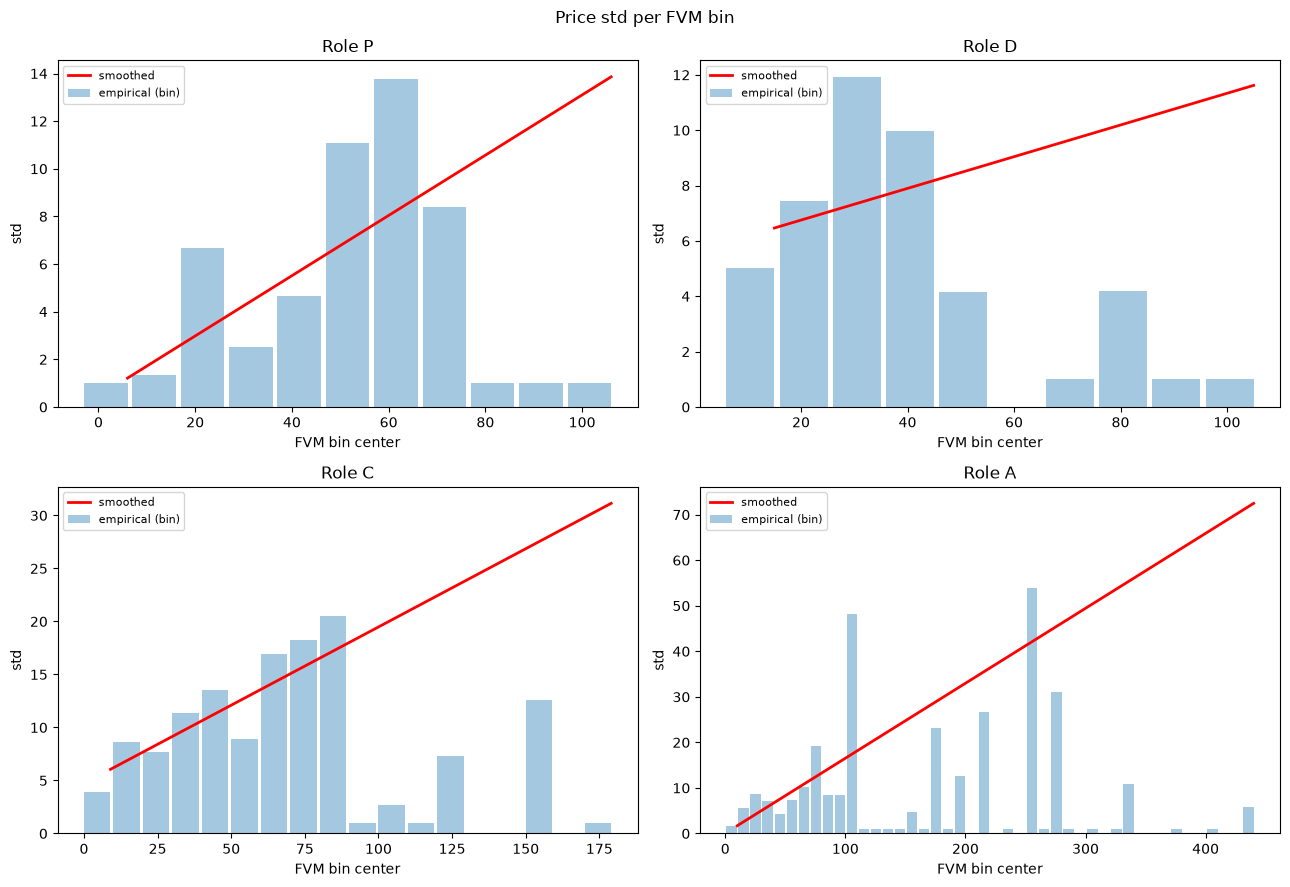

Pearson r (FVM vs price):
role
A    0.958
C    0.929
D    0.907
P    0.922


In [9]:
import matplotlib.pyplot as plt

# FVM -> price per role: players + Ridge mean + one-std band
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, role in zip(axes.flat, CFG["roles"]["major"]):
    sub = train[train["role"] == role]
    fvm, price = sub["fvm"].to_numpy(float), sub["price"].to_numpy(float)
    grid = np.linspace(max(fvm.min(), 1), fvm.max(), 200)
    mu = mean_models[role].predict(make_features(grid))
    sd = np.clip(std_models[role].predict(grid.reshape(-1, 1)), CFG["model"]["std_min"], 150)
    ax.scatter(fvm, price, s=8, alpha=0.35, label="players")
    ax.plot(grid, mu, "r-", lw=2, label="Ridge mean")
    ax.fill_between(grid, mu - sd, mu + sd, alpha=0.15, label="1 std")
    ax.set_title(f"Role {role} (n={len(sub)})")
    ax.set_xlabel("FVM"); ax.set_ylabel("price"); ax.legend(fontsize=8)
plt.suptitle("FVM -> auction price per role (aggregated players)")
plt.tight_layout(); plt.show()

# Empirical std per FVM bin + smoothed curve
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, role in zip(axes.flat, CFG["roles"]["major"]):
    b = std_bins[role]
    ax.bar(b["center"] - 4.5, b["std"], width=9, alpha=0.4, label="empirical (bin)")
    grid = np.linspace(b["center"].min(), b["center"].max(), 100)
    ax.plot(grid, std_models[role].predict(grid.reshape(-1, 1)), "r-", lw=2, label="smoothed")
    ax.set_title(f"Role {role}"); ax.set_xlabel("FVM bin center"); ax.set_ylabel("std")
    ax.legend(fontsize=8)
plt.suptitle("Price std per FVM bin")
plt.tight_layout(); plt.show()

# Correlation table (B4)
corr = train.groupby("role").apply(lambda g: g["fvm"].corr(g["price"]), include_groups=False).round(3)
print("Pearson r (FVM vs price):")
print(corr.to_string())


## Validation (C1-C5)

* **C1/C2** — player-level 80/20 hold-out (fixed seed): models are refit on the 80% and
  scored on the 20%. Per-role MAE/RMSE; overfit check = hold-out MAE < 1.2 x train MAE.
* **C3** — FVM-bin MAE table on the hold-out set: where the model over/under-predicts.
* **C4** — cross-season drift: train on the oldest auction only, predict the most recent
  auction's prices for common players. Error = model error + market drift between auctions.
* **C5** — write `data/intermediate/{SEASON}/validation_stage2a.json`.


In [10]:
# --- C1/C2: player-level 80/20 hold-out ------------------------------------
rng = np.random.default_rng(42)
train = train.assign(holdout=rng.random(len(train)) < 0.2)
tr, ho = train[~train["holdout"]], train[train["holdout"]]


def fit_mean(sub: pd.DataFrame) -> dict:
    """Per-role Ridge mean models (skip roles with < 10 samples)."""
    models = {}
    for role in CFG["roles"]["major"]:
        s = sub[sub["role"] == role]
        if len(s) < 10:
            continue
        w = s["weight"].to_numpy(float) if "weight" in s else np.ones(len(s))
        m = Pipeline([("scaler", StandardScaler()), ("ridge", Ridge(alpha=alpha))])
        m.fit(make_features(s["fvm"]), s["price"].to_numpy(float), ridge__sample_weight=w)
        models[role] = m
    return models


def predict_role_models(models: dict, sub: pd.DataFrame) -> np.ndarray:
    """Predict prices for a mixed-role frame using per-role models."""
    pred = np.empty(len(sub), dtype=float)
    for role, m in models.items():
        mask = sub["role"] == role
        if mask.any():
            pred[mask.to_numpy()] = m.predict(make_features(sub.loc[mask, "fvm"]))
    return pred


ho_models = fit_mean(tr)
ho_rows, tr_rows = [], []
for role in ho_models:
    for data, rows in ((tr, tr_rows), (ho, ho_rows)):
        s = data[data["role"] == role]
        err = predict_role_models(ho_models, s) - s["price"].to_numpy(float)
        rows.append({"role": role, "n": len(s),
                     "mae": round(float(np.abs(err).mean()), 2),
                     "rmse": round(float(np.sqrt((err ** 2).mean())), 2)})
ho_metrics = pd.DataFrame(ho_rows).set_index("role")
tr_metrics = pd.DataFrame(tr_rows).set_index("role")
print("Hold-out (out-of-sample) per-role metrics:")
print(ho_metrics.to_string())
overfit = {r: {"holdout_mae": float(ho_metrics.loc[r, "mae"]),
               "train_mae": float(tr_metrics.loc[r, "mae"]),
               "ok": bool(ho_metrics.loc[r, "mae"] < 1.2 * tr_metrics.loc[r, "mae"])}
           for r in ho_models}
print("\nOverfit check (holdout MAE < 1.2 x train MAE):")
print(pd.DataFrame(overfit).T.to_string())


Hold-out (out-of-sample) per-role metrics:
       n    mae   rmse
role                  
P      9  11.57  12.44
D     26   5.38   7.28
C     29   9.34  11.85
A     19  22.55  33.61

Overfit check (holdout MAE < 1.2 x train MAE):
  holdout_mae train_mae     ok
P       11.57      5.83  False
D        5.38      5.96   True
C        9.34      8.78   True
A       22.55     15.32  False


In [11]:
# --- C3: FVM-bin analysis on the hold-out set -------------------------------
bin_edges = [0, 10, 20, 50, 100, 200, 10 ** 6]
bin_labels = ["1-10", "11-20", "21-50", "51-100", "101-200", "200+"]
ho = ho.copy()
ho["fvm_bin"] = pd.cut(ho["fvm"], bin_edges, labels=bin_labels)
ho["pred"] = predict_role_models(ho_models, ho)
bin_metrics = (
    ho.groupby("fvm_bin", observed=True)
    .apply(lambda g: pd.Series({"mae": float((g["pred"] - g["price"]).abs().mean()),
                                "count": int(len(g)),
                                "mean_actual": float(g["price"].mean()),
                                "mean_pred": float(g["pred"].mean())}),
           include_groups=False)
    .round(2)
)
print("FVM-bin MAE (hold-out):")
print(bin_metrics.to_string())

# --- C4: cross-season drift check -------------------------------------------
# Train on the oldest auction only (its contemporaneous FVM), predict the most
# recent auction's prices (its contemporaneous FVM).
seasons = sorted(auctions["auction_season"].unique())
s_old, s_new = seasons[0], seasons[-1]


def agg_season(df: pd.DataFrame) -> pd.DataFrame:
    return (df[df["fvm"].notna()]
            .groupby(["role", "name_key", "fvm"], as_index=False)["price"].mean()
            .rename(columns={"price": "price_obs"}))


old_pl = agg_season(auctions[auctions["auction_season"] == s_old])
new_pl = agg_season(auctions[auctions["auction_season"] == s_new])
drift = old_pl.merge(new_pl, on=["role", "name_key"], how="inner",
                     suffixes=("_old", "_new"))
drift = drift.rename(columns={"fvm_new": "fvm"}).reset_index(drop=True)
drift_models = fit_mean(drift.rename(columns={"price_obs_old": "price"}))
drift["pred"] = predict_role_models(drift_models, drift)
drift_err = (drift["pred"] - drift["price_obs_new"]).abs()
print(f"\nDrift {s_old} -> {s_new}: n={len(drift)}, overall MAE={drift_err.mean():.2f}")
drift_by_role = (drift.assign(err=drift_err).groupby("role")["err"]
                 .agg(mae="mean", n="count").round(2))
print(drift_by_role.to_string())


FVM-bin MAE (hold-out):
           mae  count  mean_actual  mean_pred
fvm_bin                                      
1-10      8.47    3.0         2.91      -5.56
11-20     3.52   22.0         4.61       4.59
21-50     8.95   33.0        14.32      17.04
51-100   12.81   14.0        45.21      48.09
101-200  12.81    6.0        96.54      98.45
200+     57.73    5.0       210.41     205.48

Drift 23-24 -> 24-25: n=172, overall MAE=10.87
        mae   n
role           
A     22.44  37
C     10.86  51
D      4.91  61
P      8.12  23


In [12]:
# --- C5: validation report ---------------------------------------------------
import json

# B2 acceptance: std MAE across FVM bins (smoothed model vs empirical bin std)
std_bin_mae = {}
for role in CFG["roles"]["major"]:
    b = std_bins[role]
    pred = std_models[role].predict(b["center"].to_numpy(float).reshape(-1, 1))
    std_bin_mae[role] = round(float(np.abs(pred - b["std"]).mean()), 2)
print("Std MAE vs empirical bins (accept < 3):", std_bin_mae)

# Sanity: production-model predictions on the full training set
p_pred, s_pred = np.empty(len(train)), np.empty(len(train))
for role in CFG["roles"]["major"]:
    m = train["role"] == role
    p, s = predict_price(mean_models, std_models, train.loc[m, "fvm"], role,
                         std_min=CFG["model"]["std_min"])
    p_pred[m.to_numpy()], s_pred[m.to_numpy()] = p, s

report = {
    "season": SEASON,
    "training_auctions": seasons,
    "recency_weight": CFG["training"]["recency_weight"],
    "model_mean": CFG["model"]["mean_method"],
    "model_std": CFG["model"]["std_method"],
    "n_training_players": int(len(train)),
    "ridge_beats_baseline_roles": improved_roles,
    "per_role_metrics": {
        r: {"mae": float(ho_metrics.loc[r, "mae"]), "rmse": float(ho_metrics.loc[r, "rmse"]),
            "n_train": int(tr_metrics.loc[r, "n"]), "n_holdout": int(ho_metrics.loc[r, "n"])}
        for r in ho_models
    },
    "overfit_check": overfit,
    "std_bin_mae": std_bin_mae,
    "fvm_bin_metrics": {str(k): v for k, v in bin_metrics.to_dict("index").items()},
    "cross_season_drift": {
        "from": s_old, "to": s_new, "n_common": int(len(drift)),
        "mae": round(float(drift_err.mean()), 2),
        "per_role": {r: {"mae": float(v["mae"]), "n": int(v["n"])}
                     for r, v in drift_by_role.iterrows()},
    },
    "sanity": {"expprice": [round(float(p_pred.min()), 1), round(float(p_pred.max()), 1)],
               "expstd": [round(float(s_pred.min()), 1), round(float(s_pred.max()), 1)]},
}
out_path = Path(INTER_DIR) / "validation_stage2a.json"
out_path.write_text(json.dumps(report, indent=2))
print(f"Written {out_path}")
print(json.dumps(report["per_role_metrics"], indent=2))


Std MAE vs empirical bins (accept < 3): {'P': 4.85, 'D': 5.38, 'C': 9.2, 'A': 23.88}
Written data/intermediate/25-26/validation_stage2a.json
{
  "P": {
    "mae": 11.57,
    "rmse": 12.44,
    "n_train": 37,
    "n_holdout": 9
  },
  "D": {
    "mae": 5.38,
    "rmse": 7.28,
    "n_train": 88,
    "n_holdout": 26
  },
  "C": {
    "mae": 9.34,
    "rmse": 11.85,
    "n_train": 95,
    "n_holdout": 29
  },
  "A": {
    "mae": 22.55,
    "rmse": 33.61,
    "n_train": 71,
    "n_holdout": 19
  }
}
